# Mounting/Remounting Google Drive

In [9]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# UNZIP dataset

In [11]:
!unzip "/content/drive/MyDrive/Animal dataset.zip" -d "/content/drive/MyDrive/dataset"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/drive/MyDrive/dataset/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwH

# Check what colab see

In [12]:
import os
print(os.listdir("/content/drive/MyDrive/dataset"))

['training_set', 'test_set', 'single_prediction', 'raw-img', 'translate.py']


In [13]:
data_dir = "/content/drive/MyDrive/dataset/raw-img"

In [17]:
import tensorflow as tf

batch_size = 32
img_size = (224, 224)

# Dataset_from_directory

In [18]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

Found 26179 files belonging to 10 classes.


# Class names

In [19]:
class_names = dataset.class_names
print("Classes:", class_names)

Classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']


# Data spliting

In [20]:
total_batches = tf.data.experimental.cardinality(dataset).numpy()

train_size = int(0.7 * total_batches)
val_size = int(0.2 * total_batches)
test_size = total_batches - train_size - val_size

train_ds = dataset.take(train_size)
remaining = dataset.skip(train_size)

val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)

print("Train:", train_size)
print("Val:", val_size)
print("Test:", test_size)

Train: 573
Val: 163
Test: 83


#  Display 5 sample images for each class with their labels.

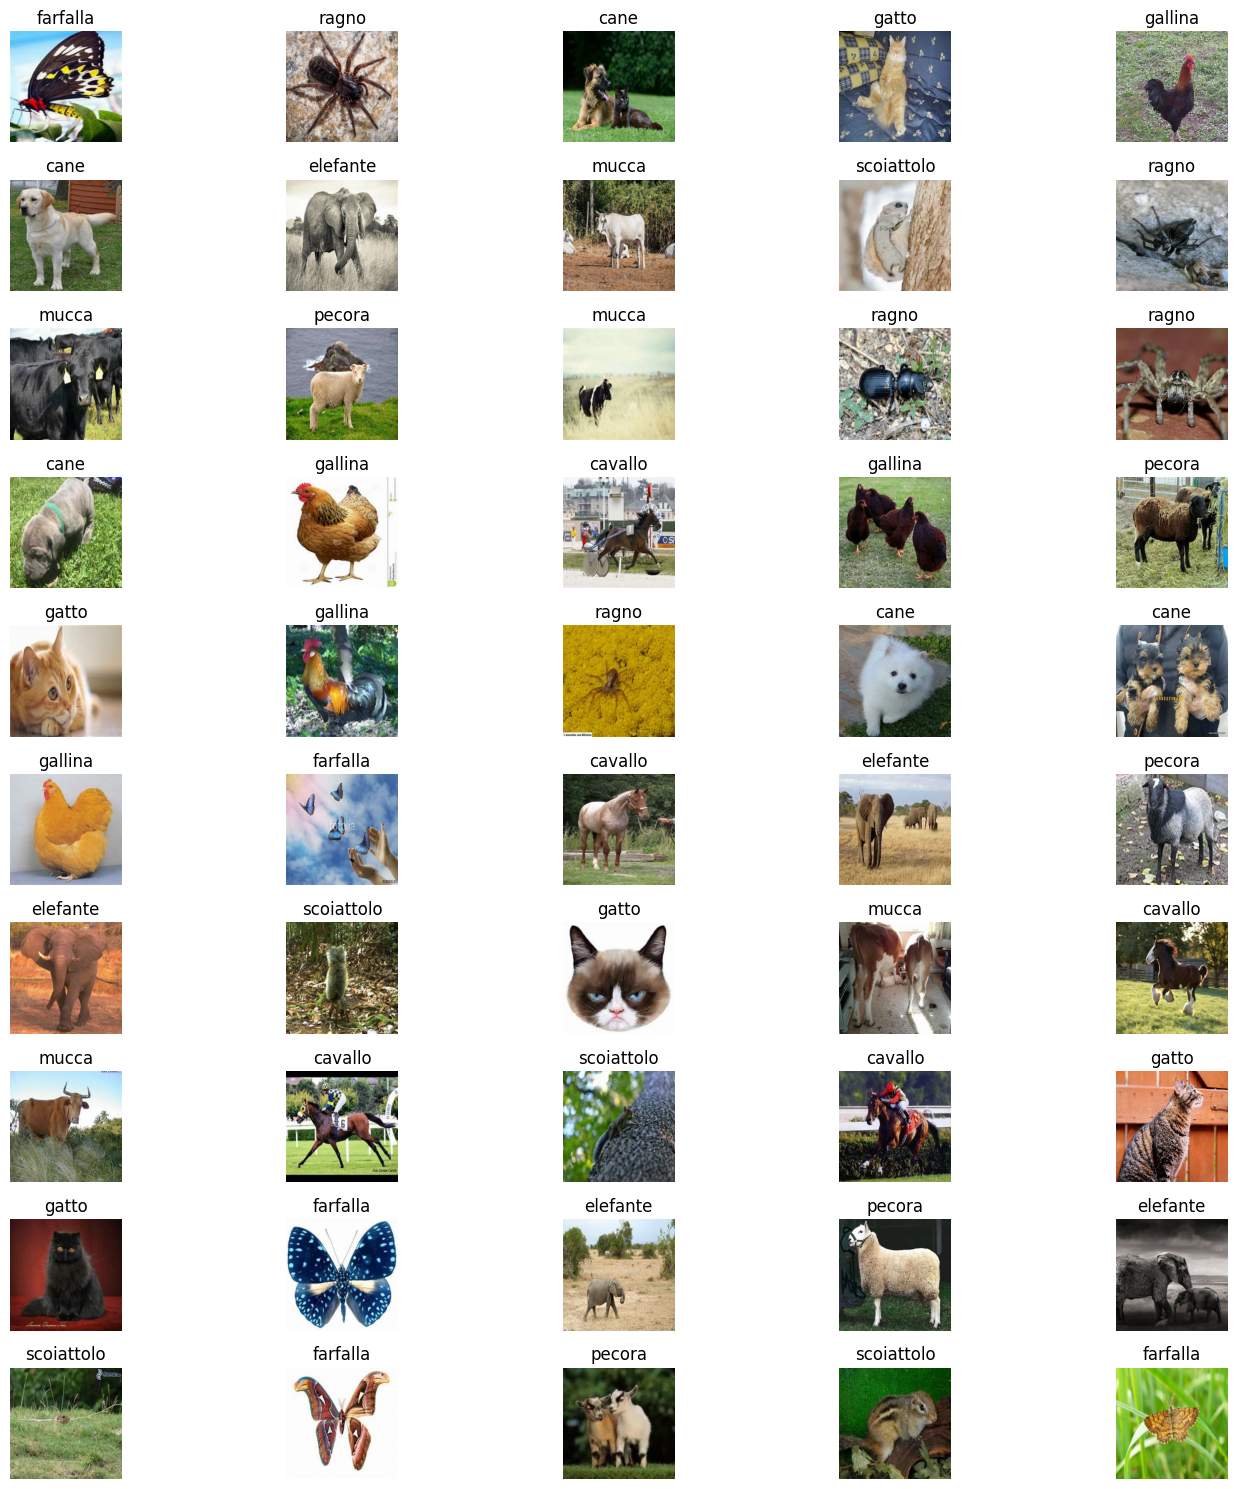

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))

class_count = {name: 0 for name in class_names}
plot_index = 1

for images, labels in train_ds.unbatch():

    label_name = class_names[labels.numpy()]

    if class_count[label_name] < 5:
        plt.subplot(10, 5, plot_index)
        plt.imshow(images.numpy().astype("uint8"))
        plt.title(label_name)
        plt.axis("off")

        class_count[label_name] += 1
        plot_index += 1

    # stop when we have 5 images for all classes
    if all(v == 5 for v in class_count.values()):
        break

plt.tight_layout()
plt.show()

# Data Augmentation


In [37]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.GaussianNoise(0.1)
])

# Model Building

Load MobileNet (Pretrained ImageNet)

In [38]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

Freeze Base Model

In [39]:
base_model.trainable = False

Build Model Inputs

In [40]:
inputs = tf.keras.Input(shape=(224, 224, 3))

Apply Augmentation (ONLY training effect)

In [41]:
x = data_augmentation(inputs)

Preprocessing + Base Model

In [42]:
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)

Custom Top Layers

In [43]:
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation='softmax')(x)

Final Model

In [44]:
model = tf.keras.Model(inputs, outputs)

Model Summary

In [45]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Why MobileNet was chosen

MobileNet was chosen because it is a lightweight and efficient deep learning model designed for mobile and low-computation environments. It uses depthwise separable convolutions, which significantly reduce the number of parameters and computation while maintaining good accuracy. This makes it suitable for wildlife classification tasks where computational resources may be limited.

Compile Model

In [46]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Early Stopping

In [47]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Train Model (MAX 50 EPOCHS)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
446/573 ━━━━━━━━━━━━━━━━━━━━ 4:22 2s/step - accuracy: 0.6612 - loss: 1.0389

Plot Loss (Training vs Validation)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Plot Accuracy

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Did overfitting occur?

Final validation accuracy

Effect of Early Stopping

At which epoch did it stop?

Get class names

In [ ]:
class_names = dataset.class_names

Take 5 test images

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

test_images = []
test_labels = []

for images, labels in test_ds.unbatch().take(5):
    test_images.append(images.numpy())
    test_labels.append(labels.numpy())

Prediction Loop

In [ ]:
for i in range(5):

    img = test_images[i]
    true_label = class_names[test_labels[i]]

    # model expects batch input
    img_input = np.expand_dims(img, axis=0)

    prediction = model.predict(img_input)

    predicted_index = np.argmax(prediction)
    predicted_label = class_names[predicted_index]

    confidence = np.max(prediction) * 100

    # show image
    plt.imshow(img.astype("uint8"))
    plt.title(f"Predicted: {predicted_label} ({confidence:.1f}%)\nGround Truth: {true_label}")
    plt.axis("off")
    plt.show()

    # print format required by assignment
    print(f"Image {i+1}: Predicted = {predicted_label} ({confidence:.1f}%), Ground Truth = {true_label}")
    print("✅" if predicted_label == true_label else "❌")
    print("-"*50)

Model Performance

Strengths

Weaknesses

Possible Improvements

# Discussion & Reflection

# Advantages of using MobileNet over training from scratch

MobileNet is a pretrained model that already has learned important image features from the ImageNet dataset. This makes it much faster to train compared to building a model from scratch, and it requires less data and computational power. It is also lightweight due to depthwise separable convolutions, making it efficient and suitable for real-world applications like wildlife classification where resources may be limited.

# How data augmentation helped

Data augmentation improved the model by increasing the diversity of training images through transformations such as flipping, rotation, zooming, and brightness changes. This helped the model generalize better by learning from different variations of the same images, reducing overfitting, and making it more robust to real-world conditions like lighting changes and different camera angles.

# What would you improve given more time/compute

With more time and computational resources, I would improve the model by unfreezing and fine-tuning deeper layers of MobileNet to better adapt it to the wildlife dataset. I would also increase the dataset size, try more advanced architectures like EfficientNet, and perform hyperparameter tuning (learning rate, batch size, dropout) to further improve accuracy and reduce errors.